In [38]:
# initially connecting google Drive with colab

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [39]:
import pandas as pd
import numpy as np
# Load the Titanic dataset
data = pd.read_csv("/content/drive/MyDrive/Workshop_4_csv/Titanic-Dataset.csv")
# Drop all categorical columns except 'Survived'
categorical_columns = data.select_dtypes(include=['object']).columns
data = data.drop(columns=[col for col in categorical_columns if col != 'Survived'])
# Check for missing values
missing_info = data.isnull().sum() / len(data) * 100
# Handle missing values
for column in data.columns:
  if missing_info[column] > 10: # If more than 10% missing
    data[column].fillna(data[column].mean(), inplace=True)
  else: # If less than 10% missing
    data.dropna(subset=[column], inplace=True)
# Display cleaned data
print("Data after processing:\n", data.head())
print("\nMissing values after processing:\n", data.isnull().sum())

Data after processing:
    PassengerId  Survived  Pclass   Age  SibSp  Parch     Fare
0            1         0       3  22.0      1      0   7.2500
1            2         1       1  38.0      1      0  71.2833
2            3         1       3  26.0      0      0   7.9250
3            4         1       1  35.0      1      0  53.1000
4            5         0       3  35.0      0      0   8.0500

Missing values after processing:
 PassengerId    0
Survived       0
Pclass         0
Age            0
SibSp          0
Parch          0
Fare           0
dtype: int64


/tmp/ipython-input-52877881.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[column].fillna(data[column].mean(), inplace=True)


In [40]:
# Separate features (X) and target (y)
X = data.drop(columns=['Survived']).values # Convert features to NumPy array
y = data['Survived'].values # Convert target to NumPy array
# Define a function for train-test split from scratch

def train_test_split_scratch(X, y, test_size=0.3, random_seed=42):
  """
  Splits dataset into train and test sets.
  Arguments:
  X : np.ndarray
    Feature matrix.
  y : np.ndarray
    Target array.
  test_size : float
    Proportion of the dataset to include in the test split (0 < test_size < 1).
  random_seed : int
    Seed for reproducibility.
  Returns:
  X_train, X_test, y_train, y_test : np.ndarray
    Training and testing splits of features and target.
  """
  np.random.seed(random_seed)
  indices = np.arange(X.shape[0])
  np.random.shuffle(indices) # Shuffle the indices
  test_split_size = int(len(X) * test_size)
  test_indices = indices[:test_split_size]
  train_indices = indices[test_split_size:]
  X_train, X_test = X[train_indices], X[test_indices]
  y_train, y_test = y[train_indices], y[test_indices]
  return X_train, X_test, y_train, y_test
# Perform the train-test split
X_train, X_test, y_train, y_test = train_test_split_scratch(X, y, test_size=0.3)

print(X_train)
# Output shapes to verify
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

[[431.           1.          28.           0.           0.
   26.55      ]
 [446.           1.           4.           0.           2.
   81.8583    ]
 [651.           3.          29.69911765   0.           0.
    7.8958    ]
 ...
 [861.           3.          41.           2.           0.
   14.1083    ]
 [436.           1.          14.           1.           2.
  120.        ]
 [103.           1.          21.           0.           1.
   77.2875    ]]
Shape of X_train: (624, 6)
Shape of X_test: (267, 6)
Shape of y_train: (624,)
Shape of y_test: (267,)


In [41]:
def euclidean_distance(point1, point2):
  """
  Calculate the Euclidean distance between two points in n-dimensional space.
  Arguments:
  point1 : np.ndarray
    The first point as a numpy array.
  point2 : np.ndarray
    The second point as a numpy array.
  Returns:
  float
    The Euclidean distance between the two points.
  Raises:
    ValueError: If the input points do not have the same dimensionality.
  """
  # Check if the points are of the same dimension
  if point1.shape != point2.shape:
    raise ValueError("Points must have the same dimensions to calculate Euclidean distance.")
  # Calculate the Euclidean distance
  distance = np.sqrt(np.sum((point1 - point2) ** 2))
  return distance

In [42]:
# Test case for the function
try:
  # Define two points
  point1 = np.array([3, 4])
  point2 = np.array([0, 0])
  # Calculate the distance
  result = euclidean_distance(point1, point2)
  # Check if the result matches the expected value (e.g., sqrt(3^2 + 4^2) = 5)
  expected_result = 5.0
  assert np.isclose(result, expected_result), f"Expected {expected_result}, but got {result}"
  print("Test passed successfully!")
except ValueError as ve:
  print(f"ValueError: {ve}")
except AssertionError as ae:
  print(f"AssertionError: {ae}")
except Exception as e:
  print(f"An unexpected error occurred: {e}")

Test passed successfully!


In [43]:
# Function for KNN prediction for a single query
def knn_predict_single(query, X_train, y_train, k=3):
  """
  Predict the class label for a single query using the K-nearest neighbors algorithm.
  Arguments:
  query : np.ndarray
    The query point for which the prediction is to be made.
  X_train : np.ndarray
    The training feature matrix.
  y_train : np.ndarray
    The training labels.
  k : int, optional
    The number of nearest neighbors to consider (default is 3).
  Returns:
  int
    The predicted class label for the query.
  """
  distances = [euclidean_distance(query, x) for x in X_train]
  sorted_indices = np.argsort(distances)
  nearest_indices = sorted_indices[:k]
  nearest_labels = y_train[nearest_indices]
  prediction = np.bincount(nearest_labels).argmax()
  return prediction

In [44]:
# Function to test KNN for all test samples
def knn_predict(X_test, X_train, y_train, k=3):
  """
  Predict the class labels for all test samples using the K-nearest neighbors algorithm.
  Arguments:
  X_test : np.ndarray
    The test feature matrix.
  X_train : np.ndarray
    The training feature matrix.
  y_train : np.ndarray
    The training labels.
  k : int, optional
    The number of nearest neighbors to consider (default is 3).
  Returns:
  np.ndarray
    An array of predicted class labels for the test samples.
  """
  predictions = [knn_predict_single(x, X_train, y_train, k) for x in X_test]
  return np.array(predictions)

In [45]:
# Test case for KNN on the Titanic dataset
# Assume X_train, X_test, y_train, and y_test have been prepared using the code above
try:
  # Define the test set for the test case
  X_test_sample = X_test[:5] # Taking a small subset for testing
  y_test_sample = y_test[:5] # Corresponding labels for the subset
  # Make predictions
  predictions = knn_predict(X_test_sample, X_train, y_train, k=3)
  # Print test results
  print("Predictions:", predictions)
  print("Actual labels:", y_test_sample)
  # Check if predictions match expected format
  assert predictions.shape == y_test_sample.shape, "The shape of predictions does not match the shape of the actual labels."
  print("Test case passed successfully!")
except AssertionError as ae:
  print(f"AssertionError: {ae}")
except Exception as e:
  print(f"An unexpected error occurred: {e}")

Predictions: [0 1 0 0 0]
Actual labels: [1 0 0 1 1]
Test case passed successfully!


In [46]:
# Function to compute accuracy of predictions
def compute_accuracy(y_true, y_pred):
  """
  Compute the accuracy of predictions.
  Arguments:
  y_true : np.ndarray ; The true labels.
  y_pred : np.ndarray; The predicted labels.
  Returns:
  float : The accuracy as a percentage (0 to 100).
  """
  correct_predictions = np.sum(y_true == y_pred)
  total_predictions = len(y_true)
  accuracy = (correct_predictions / total_predictions) * 100
  return accuracy

In [47]:
# Perform prediction on the entire test set
try:
  # Make predictions on the entire test set
  predictions = knn_predict(X_test, X_train, y_train, k=3)
  # Compute the accuracy
  accuracy = compute_accuracy(y_test, predictions)
  # Print the accuracy
  print(f"Accuracy of the KNN model on the test set: {accuracy:.2f}%")
except Exception as e:
  print(f"An unexpected error occurred during prediction or accuracy computation: {e}")

Accuracy of the KNN model on the test set: 61.80%


In [48]:
# Function to test KNN on different values of k and plot the accuracies
import matplotlib.pyplot as plt
def experiment_knn_k_values(X_train, y_train, X_test, y_test, k_values):
  """
  Run KNN predictions for different values of k and plot the accuracies.
  Arguments:
  X_train : np.ndarray
    The training feature matrix.
  y_train : np.ndarray
    The training labels.
  X_test : np.ndarray
    The test feature matrix.
  y_test : np.ndarray
    The test labels.
  k_values : list of int
    A list of k values to experiment with.
  Returns:
  dict
    A dictionary with k values as keys and their corresponding accuracies as values.
  """
  accuracies = {}
  for k in k_values:
    # Make predictions using the current value of k
    predictions = knn_predict(X_test, X_train, y_train, k=k)
    # Compute the accuracy
    accuracy = compute_accuracy(y_test, predictions)
    accuracies[k] = accuracy
    print(f"Accuracy for k={k}: {accuracy:.2f}%")
    # Plot the accuracies
  plt.figure(figsize=(10, 5))
  plt.plot(k_values, list(accuracies.values()), marker='o')
  plt.xlabel('k (Number of Neighbors)')
  plt.ylabel('Accuracy (%)')
  plt.title('Accuracy of KNN with Different Values of k')
  plt.grid(True)
  plt.show()
  return accuracies

Accuracy for k=1: 58.43%
Accuracy for k=2: 62.55%
Accuracy for k=3: 61.80%
Accuracy for k=4: 63.30%
Accuracy for k=5: 64.42%
Accuracy for k=6: 64.42%
Accuracy for k=7: 65.17%
Accuracy for k=8: 64.42%
Accuracy for k=9: 65.17%
Accuracy for k=10: 64.04%
Accuracy for k=11: 64.04%
Accuracy for k=12: 64.79%
Accuracy for k=13: 64.79%
Accuracy for k=14: 65.92%
Accuracy for k=15: 65.17%
Accuracy for k=16: 65.92%
Accuracy for k=17: 66.67%
Accuracy for k=18: 66.29%
Accuracy for k=19: 67.79%
Accuracy for k=20: 64.79%


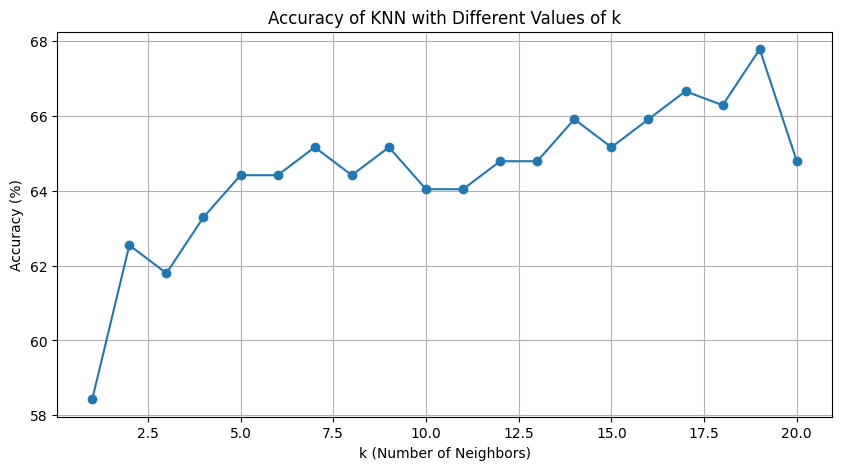

Experiment completed. Check the plot for the accuracy trend.


In [49]:
# Define the range of k values to experiment with
k_values = range(1, 21) # You can adjust this range as needed
# Run the experiment
try:
  accuracies = experiment_knn_k_values(X_train, y_train, X_test, y_test, k_values)
  print("Experiment completed. Check the plot for the accuracy trend.")
except Exception as e:
  print(f"An unexpected error occurred during the experiment: {e}")

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [51]:
diabetes_df = pd.read_csv("/content/drive/MyDrive/Workshop_4_csv/diabetes_.csv")
diabetes_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [52]:
diabetes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [53]:
diabetes_df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


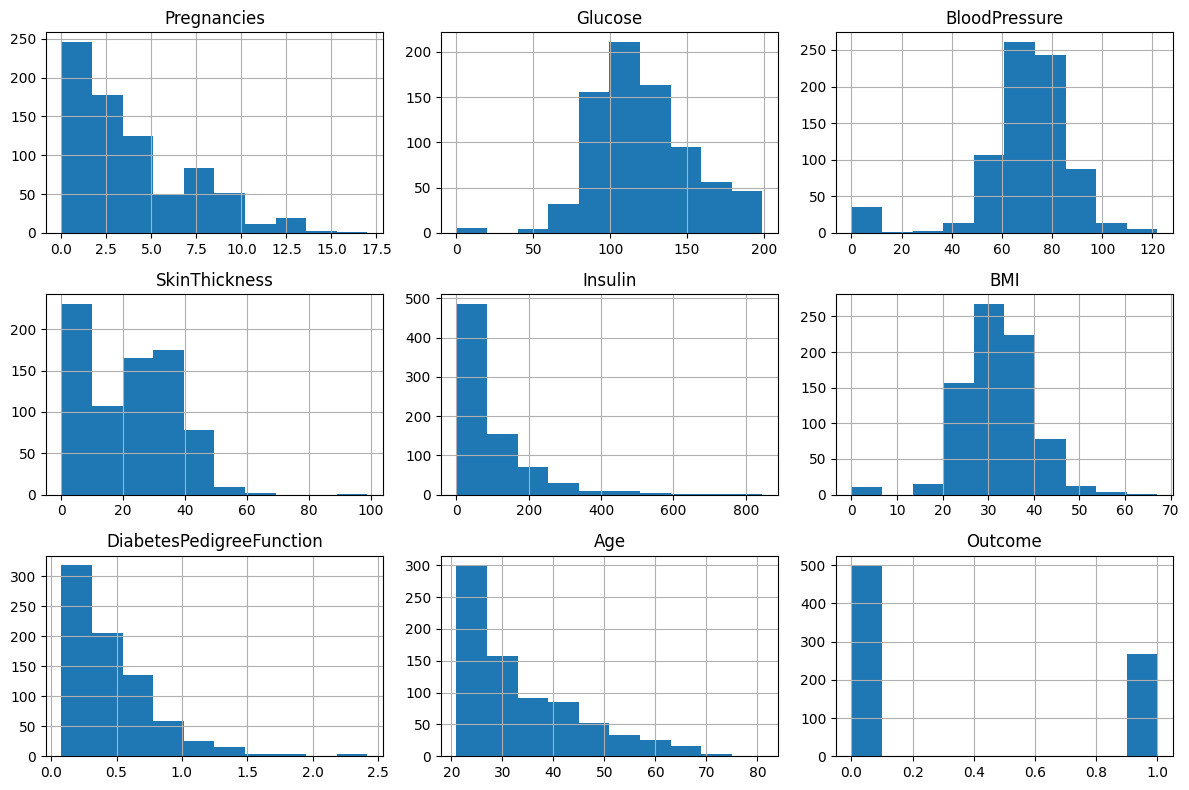

In [54]:
import matplotlib.pyplot as plt

diabetes_df.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()


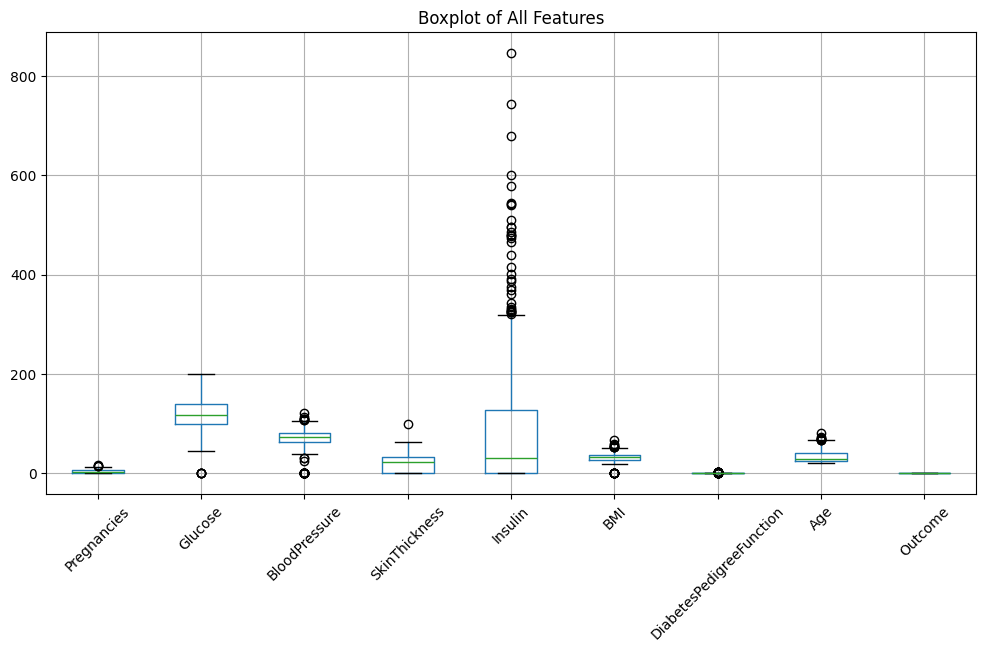

In [55]:
plt.figure(figsize=(12, 6))
diabetes_df.boxplot()
plt.xticks(rotation=45)
plt.title("Boxplot of All Features")
plt.show()


In [56]:
diabetes_df_totalnulls = diabetes_df.isnull().sum()
print(f"Total number of null values in each column: \n{diabetes_df_totalnulls}")

if diabetes_df_totalnulls.sum() == 0:
    print("\nDiabetes dataset has no missing values.")

Total number of null values in each column: 
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Diabetes dataset has no missing values.


In [57]:
# Declaring A Function to Split the Dataset in Training and Testing Data

def train_test_split_func(features, target, test_size=0.3, random_seed=42):
  """
  Splits a dataset into training and testing sets.

  Parameters :
  features : np.ndarray
    Feature matrix (rows = data samples, columns = freatures).
  target : np.ndarray
    Target array.
  test_size : float
    Proportion of data to allocate to the test set (0 < test_size < 1).
    Default: 0.3.
  random_seed : int
    Seed for random number generator to ensure reproducibility.
    Default: 42.

  Returns:
  X_train : np.ndarray
    Training features.
  X_test : np.ndarray
    Testing features.
  y_train : np.ndarray
    Training target values.
  y_test : np.ndarray
    Testing target values.
  """
  # Setting a random seed for reproducibility
  np.random.seed(random_seed)

  # Shuffling data indices
  indices = np.arange(X.shape[0])
  np.random.shuffle(indices)

  # Determineing number of test samples
  test_split_size = int(len(features) * test_size)

  # spliting indices into train and test indices
  test_indices = indices[:test_split_size]
  train_indices = indices[test_split_size:]

  # Creating training and testing sets
  X_train, X_test = X[train_indices], X[test_indices]
  y_train, y_test = y[train_indices], y[test_indices]
  return X_train, X_test, y_train, y_test


In [58]:
# Separating features and targets
features = diabetes_df.iloc[:, :-1].values
target = diabetes_df.iloc[:, -1].values

# Spitting the data into training and testing sets 70 - 30 %
X_train, X_test, y_train, y_test = train_test_split_func(features, target, test_size=0.3, random_seed=42)

# Outputs
# Features training set
print(f"Feature Training set: \n]n{X_train}\n")

# Featrues testing set
print(f"Feature Testing set: \n\n{X_test}")

Feature Training set: 
]n[[406.           2.          34.           1.           0.
   21.        ]
 [743.           1.          21.           2.           2.
  262.375     ]
 [261.           3.          29.69911765   0.           0.
    7.75      ]
 ...
 [861.           3.          41.           2.           0.
   14.1083    ]
 [436.           1.          14.           1.           2.
  120.        ]
 [103.           1.          21.           0.           1.
   77.2875    ]]

Feature Testing set: 

[[710.           3.          29.69911765   1.           1.
   15.2458    ]
 [440.           2.          31.           0.           0.
   10.5       ]
 [841.           3.          20.           0.           0.
    7.925     ]
 ...
 [306.           1.           0.92         1.           2.
  151.55      ]
 [317.           2.          24.           1.           0.
   26.        ]
 [  3.           3.          26.           0.           0.
    7.925     ]]


In [59]:

# Creating a function for calculating KNN prediction for a single query
def knn_predict_single_values(query, X_train, y_train, k=3):
  """
  This function predicts the class label for a single query(Actual Data X)
  using the K-nearest neighbors algorithm(KNN).

  Parameters:
  query : np.ndarray
    The query point for prediction .
  X_train : np.ndarray
  The training feature matrix.
  y_train : np.ndarray
  The training labels.
  k : int, optional
  The number of nearest neighbors to consider (default is 3).
  Returns:
  int
  The predicted class label for the query.
  """
  distances_calculation = [euclidean_distance(query, x) for x in X_train]
  sorted_indices = np.argsort(distances_calculation)
  indices_nearest_K = sorted_indices[:k]
  labels_nearest_K = y_train[indices_nearest_K]

  # Counting majority
  prediction = np.bincount(labels_nearest_K).argmax()
  return prediction


# Creating a function for calculating KNN prediction for for all samples
def knn_predict_whole(X_test, X_train, y_train, k=3):
  """
  This function predicts the class labels for all test samples using the
  K-nearest neighbors algorithm(KNN).

  Parameters:

  X_train : np.ndarray
    Training features.
  X_test : np.ndarray
    Testing features.
  y_train : np.ndarray
    Training target values.
  k : int
    Number of nearest neighbors to consider.

  Returns:
  np.ndarray
    Returns an array of predicted class labels for the test samples.
  """
  KNN_predictions = [knn_predict_single_values(x, X_train, y_train, k) for x in X_test]
  return np.array(KNN_predictions)

In [60]:
# Creating a function to calculate the eculidean distance between two points
def euclidean_distance(point1, point2):
  """
  This function calculate the Euclidean distance between two points in
  n-dimensional space.

  Parameters:
  point1 : np.ndarray
    The first point(co-ordinate) as a numpy array.
  point2 : np.ndarray
    The second point(co-ordinate) as a numpy array.

  Returns:
  float:
    returns the Euclidean distance between the two points.
  Raises:
    ValueError: raises an error if the points does not have same dimensionality.
  """

  # Checking whethe the points have the same dimenstionality
  if point1.shape != point2.shape:
    raise ValueError("To calculate the Euclidean distance, the point must be of same dimensionality.")

  # Calculating Euclidean distance (d(\mathbf{p,q})=\sqrt{\sum _{i=1}^{n}(q_{i}-p_{i})^{2}}\)
  ecu_distance = np.sqrt(np.sum((point1 - point2) ** 2))
  return ecu_distance

In [61]:
# Creating a function to compute accurary of predictions
def compute_accuracy(y_true, y_pred):
  """
  Compute the accuracy of predictions.
  Arguments:
  y_true : np.ndarray ; The true labels.
  y_pred : np.ndarray; The predicted labels.
  Returns:
  float : The accuracy as a percentage (0 to 100).
  """
  accurate_predictions = np.sum(y_true == y_pred)
  total_predictions = len(y_true)
  accuracy_per = (accurate_predictions / total_predictions) * 100
  return accuracy_per

Accuracy k=1: 57.39%
Accuracy k=3: 60.43%
Accuracy k=5: 64.35%
Accuracy k=7: 65.22%
Accuracy k=9: 65.22%
Accuracy k=11: 64.35%
Accuracy k=13: 65.22%
Accuracy k=15: 65.65%
Accuracy k=17: 65.65%
Accuracy k=19: 68.26%
Accuracy k=21: 66.09%
Accuracy k=23: 68.26%
Accuracy k=25: 66.96%
Accuracy k=27: 67.83%
Accuracy k=29: 66.96%
Accuracy k=31: 66.96%
Accuracy k=33: 66.09%
Accuracy k=35: 65.22%
Accuracy k=37: 63.91%
Accuracy k=39: 62.61%
Accuracy k=41: 63.04%
Accuracy k=43: 63.04%
Accuracy k=45: 63.04%
Accuracy k=47: 63.48%
Accuracy k=49: 63.48%


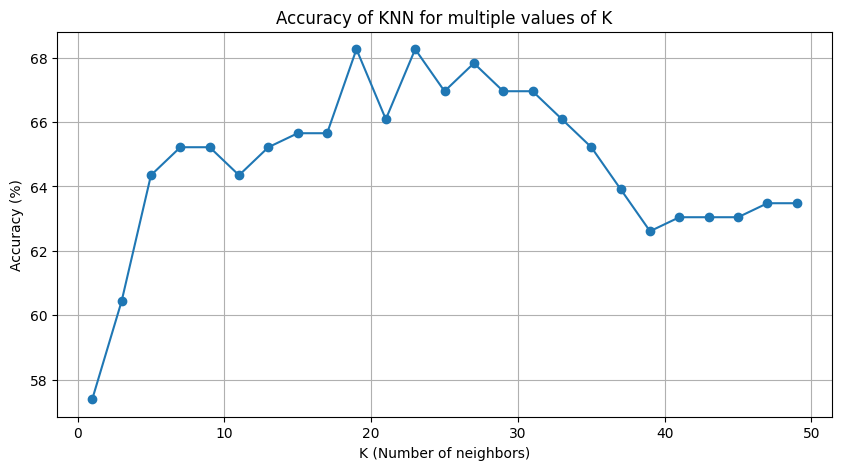

Completion of Accuracy Experiment with Different K Values.


In [62]:
# Creating a function for to test KNN on different values of k and plot the accuracies
def experiment_knn_k_values(X_train, y_train, X_test, y_test, k_values):
  """
  The function runs knn_predict_whole to compute predictions for
  different values of k and plot their accuracies along with their prediction time.

  Parameters:
  X_train : np.ndarray
    Training features.
  y_train : np.ndarray
    Training target values.
  X_test : np.ndarray
    Testing features.
  y_test : np.ndarray
    Testing target values.
  k_values : list with int values
    list with int values to experiment with.

  Returns:
  dict :
    returns a dictionary with k = keys and their corresponding accuracies as values.
  """
  results = {}
  different_accuracies = {}
  prediction_times = {}

  for k in k_values:

    # Starting the timer
    start_time = time.time()

    # Making predictions for K = current values.
    predictions = knn_predict_whole(X_test, X_train, y_train, k=k)
    # Computing the accuracy
    accuracy = compute_accuracy(y_test, predictions)
    different_accuracies[k] = accuracy
    print(f"Accuracy k={k}: {accuracy:.2f}%")

    # Plotting the accuracies
  plt.figure(figsize=(10, 5))
  plt.plot(k_values, list(different_accuracies.values()), marker='o')
  plt.xlabel('K (Number of neighbors)')
  plt.ylabel('Accuracy (%)')
  plt.title('Accuracy of KNN for multiple values of K')
  plt.grid(True)
  plt.show()
  return different_accuracies

# Defining K range for experiment
k_values = range(1, 50, 2) # odd K values only

try:
  accuracies = experiment_knn_k_values(X_train, y_train, X_test, y_test, k_values)
  print("Completion of Accuracy Experiment with Different K Values.")
except Exception as e:
  print(f"An unexpected error occurred during the experiment: {e}")

In [63]:
# Creating a function that will Scale (Normalize) the Feature Matrux X
def scale_normalize(X):
  """
  This function will scale the feature matrix X.

  Parameters:
  X : np.ndarray
    Acutal Data Feature

  Returns:
  np.ndarray
    Returns the scaled feature matrix.

  """
  normalize_scale = (X - X.min(axis = 0) / X.max(axis = 0) - X.min(axis = 0))
  return normalize_scale

# Calling scale_feature
features_scaled = scale_normalize(features)

# Verifying output
print(f"Caluclated Scaled Features: \n\n{features_scaled}")

Caluclated Scaled Features: 

[[6.00000000e+00 1.48000000e+02 7.20000000e+01 ... 3.36000000e+01
  5.16768595e-01 2.87407407e+01]
 [1.00000000e+00 8.50000000e+01 6.60000000e+01 ... 2.66000000e+01
  2.40768595e-01 9.74074074e+00]
 [8.00000000e+00 1.83000000e+02 6.40000000e+01 ... 2.33000000e+01
  5.61768595e-01 1.07407407e+01]
 ...
 [5.00000000e+00 1.21000000e+02 7.20000000e+01 ... 2.62000000e+01
  1.34768595e-01 8.74074074e+00]
 [1.00000000e+00 1.26000000e+02 6.00000000e+01 ... 3.01000000e+01
  2.38768595e-01 2.57407407e+01]
 [1.00000000e+00 9.30000000e+01 7.00000000e+01 ... 3.04000000e+01
  2.04768595e-01 1.74074074e+00]]


In [64]:
X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled = train_test_split_func(
    features_scaled, target, test_size=0.3, random_seed=42
)

# Verifying
print("Shape of X_train_scaled:", X_train_scaled.shape)
print("Shape of X_test_scaled:", X_test_scaled.shape)
print("Shape of y_train_scaled:", y_train_scaled.shape)
print("Shape of y_test_scaled:", y_test_scaled.shape)

Shape of X_train_scaled: (661, 6)
Shape of X_test_scaled: (230, 6)
Shape of y_train_scaled: (661,)
Shape of y_test_scaled: (230,)


Accuracy k=1: 57.39%
Accuracy k=3: 60.43%
Accuracy k=5: 64.35%
Accuracy k=7: 65.22%
Accuracy k=9: 65.22%
Accuracy k=11: 64.35%
Accuracy k=13: 65.22%
Accuracy k=15: 65.65%
Accuracy k=17: 65.65%
Accuracy k=19: 68.26%
Accuracy k=21: 66.09%
Accuracy k=23: 68.26%
Accuracy k=25: 66.96%
Accuracy k=27: 67.83%
Accuracy k=29: 66.96%
Accuracy k=31: 66.96%
Accuracy k=33: 66.09%
Accuracy k=35: 65.22%
Accuracy k=37: 63.91%
Accuracy k=39: 62.61%
Accuracy k=41: 63.04%
Accuracy k=43: 63.04%
Accuracy k=45: 63.04%
Accuracy k=47: 63.48%
Accuracy k=49: 63.48%


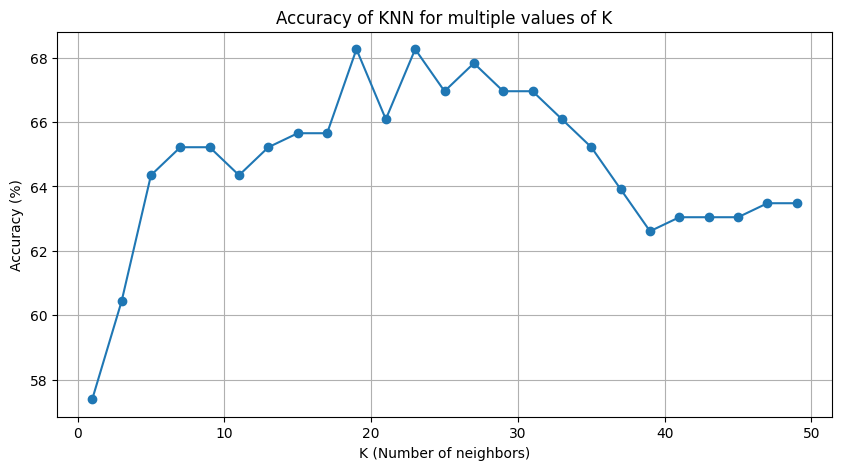

Completion of Accuracy Experiment with Different K Values.


In [65]:
# Defining K range for experiment
k_values = range(1, 50, 2) # odd K values only

try:
  accuracies = experiment_knn_k_values(X_train_scaled, y_train_scaled, X_test_scaled, y_test_scaled, k_values)
  print("Completion of Accuracy Experiment with Different K Values.")
except Exception as e:
  print(f"An unexpected error occurred during the experiment: {e}")


In [66]:
# Importing time module
import time

# Creating a function for to test KNN on different values of k and plot the accuracies and elapsed time
def experiment_knn_k_values(X_train, y_train, X_test, y_test, k_values):
  """
  The function runs knn_predict_whole to compute predictions for
  different values of k and plot their accuracies along with their prediction time.

  Parameters:
  X_train : np.ndarray
    Training features.
  y_train : np.ndarray
    Training target values.
  X_test : np.ndarray
    Testing features.
  y_test : np.ndarray
    Testing target values.
  k_values : list with int values
    list with int values to experiment with.

  Returns:
  dict :
    returns a dictionary with accuracy and time.
  """
  results = {}
  different_accuracies = []
  prediction_times = []

  for k in k_values:

    # Starting the timer
    start_time = time.time()

    # Making predictions for K = current values.
    predictions = knn_predict_whole(X_test, X_train, y_train, k=k)

    # Ending the timer
    end_time = time.time()

    # Calculating elapsed time
    elapsed_time = end_time - start_time

    # Computing the accuracy
    accuracy = compute_accuracy(y_test, predictions)

    results[k] = {
            "accuracy": accuracy,
            "time": elapsed_time
        }

    # Appending the results to the lists
    different_accuracies.append(accuracy)
    prediction_times.append(elapsed_time)

    print(f"K values={k} | Accuracy={accuracy:.2f}% | Time={elapsed_time:.4f}s")

  return results


In [74]:
# Defining K range for experiment
k_values = range(1, 15) # odd K values only

try:
  original_results = experiment_knn_k_values(
      X_train, y_train, X_test, y_test, k_values
  )

  scaled_results = experiment_knn_k_values(
      X_train_scaled, y_train_scaled, X_test_scaled, y_test_scaled, k_values
  )

  print("Completion of Accuracy Experiment with Different K Values.")
except Exception as e:
  print(f"An unexpected error occurred during the experiment: {e}")



K values=1 | Accuracy=57.39% | Time=1.8966s
K values=2 | Accuracy=60.87% | Time=1.8063s
K values=3 | Accuracy=60.43% | Time=1.0849s
K values=4 | Accuracy=63.04% | Time=1.0816s
K values=5 | Accuracy=64.35% | Time=1.0910s
K values=6 | Accuracy=64.78% | Time=1.0852s
K values=7 | Accuracy=65.22% | Time=1.0850s
K values=8 | Accuracy=64.78% | Time=1.1316s
K values=9 | Accuracy=65.22% | Time=1.0787s
K values=10 | Accuracy=66.09% | Time=1.0963s
K values=11 | Accuracy=64.35% | Time=1.4645s
K values=12 | Accuracy=64.78% | Time=2.1037s
K values=13 | Accuracy=65.22% | Time=1.9974s
K values=14 | Accuracy=66.52% | Time=1.2304s
K values=1 | Accuracy=57.39% | Time=1.1978s
K values=2 | Accuracy=60.87% | Time=1.1166s
K values=3 | Accuracy=60.43% | Time=1.0951s
K values=4 | Accuracy=63.04% | Time=1.0728s
K values=5 | Accuracy=64.35% | Time=1.1356s
K values=6 | Accuracy=64.78% | Time=1.1220s
K values=7 | Accuracy=65.22% | Time=1.1496s
K values=8 | Accuracy=64.78% | Time=1.3667s
K values=9 | Accuracy=65.22

In [78]:

def plot_knn_accuracy(results, title="KNN Accuracy vs K"):
    """
    This function plots the accuracy of KNN for different values of K.

    Parameters:
    results : dict
        A dictionary containing the accuracy results for different values of K.

    Returns:
    None
    """
    k_values = list(results.keys())
    accuracies = [results[k]["accuracy"] for k in k_values]

    plt.figure(figsize=(10, 5))
    plt.plot(k_values, accuracies, marker='o')
    plt.xlabel("K (Number of neighbors)")
    plt.ylabel("Accuracy (%)")
    plt.title(title)
    plt.grid(True)
    plt.show()

def plot_knn_time(results, title="KNN Prediction Time vs K"):
    """
    This function plots the computation time of KNN for different values of K.

    Parameters:
    results : dict
        A dictionary containing the computation time results for different
        values of K.

    Returns:
    None
    """
    k_values = list(results.keys())
    times = [results[k]["time"] for k in k_values]

    plt.figure(figsize=(10, 5))
    plt.plot(k_values, times, marker='o')
    plt.xlabel("K (Number of neighbors)")
    plt.ylabel("Time (seconds)")
    plt.title(title)
    plt.grid(True)
    plt.show()


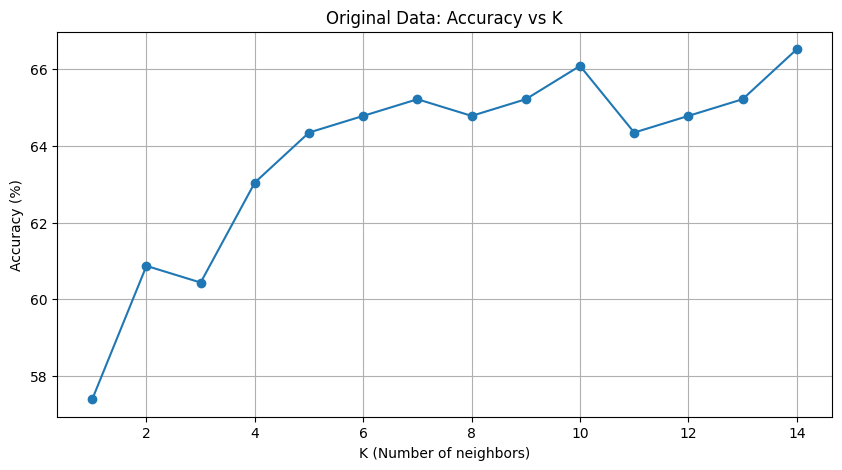

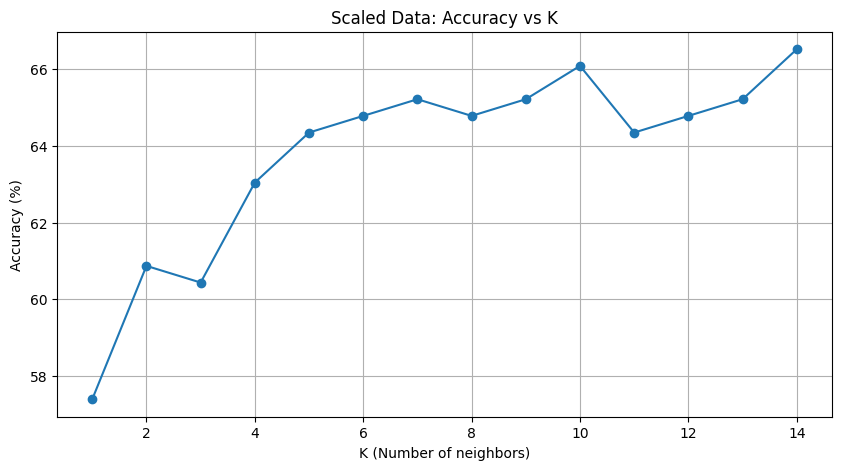

In [80]:
plot_knn_accuracy(original_results, "Original Data: Accuracy vs K")
plot_knn_accuracy(scaled_results, "Scaled Data: Accuracy vs K")



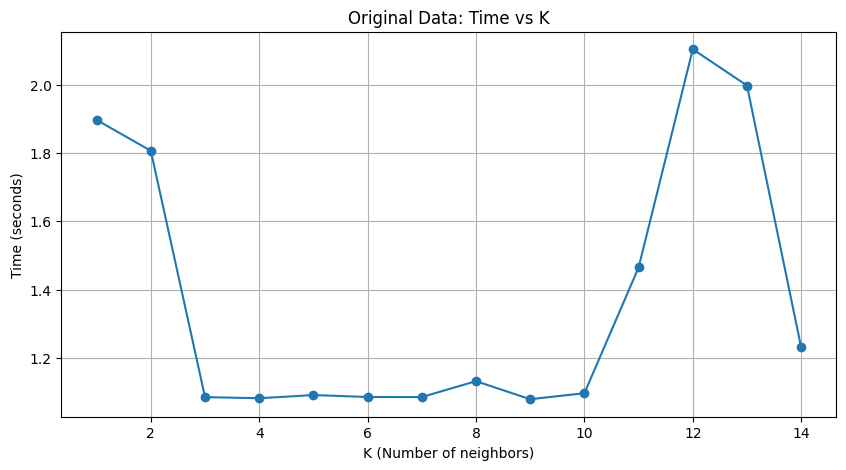

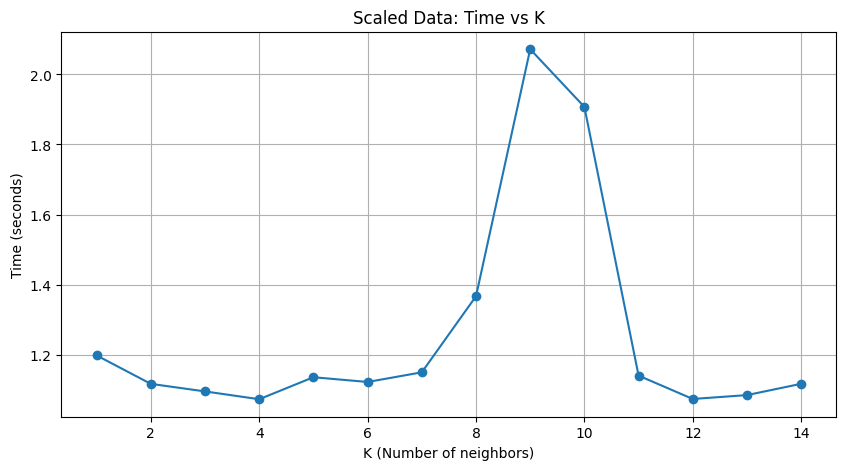

In [79]:
plot_knn_time(original_results, "Original Data: Time vs K")
plot_knn_time(scaled_results, "Scaled Data: Time vs K")